In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

df = pd.read_csv('../data/processed/zomato_clean.csv')
print(df.shape)

(211944, 21)



# Brainstorm question

1. What % of restaurants are zero-rated (unrated), and does it vary by city?
2. Which Indian cities have the highest-rated restaurants (filtered to rated)?
3. Which localities have the highest concentration of top-rated restaurants?
4. Which cuisines dominate which cities? Are there regional cuisine signatures?
5. For chain restaurants present in multiple cities, how much does pricing vary?
6. Which restaurant attributes (delivery, AC, alcohol, pure-veg) correlate with higher ratings?
7. Which cities have low engagement — low votes-per-restaurant despite many restaurants?
8. Does higher average cost correlate with higher ratings? How does the variance change?
9. Where are the "hidden gems" — high rating but low vote count?
10. How does pricing vary by establishment type (Quick Bites vs Fine Dining vs Bar)?


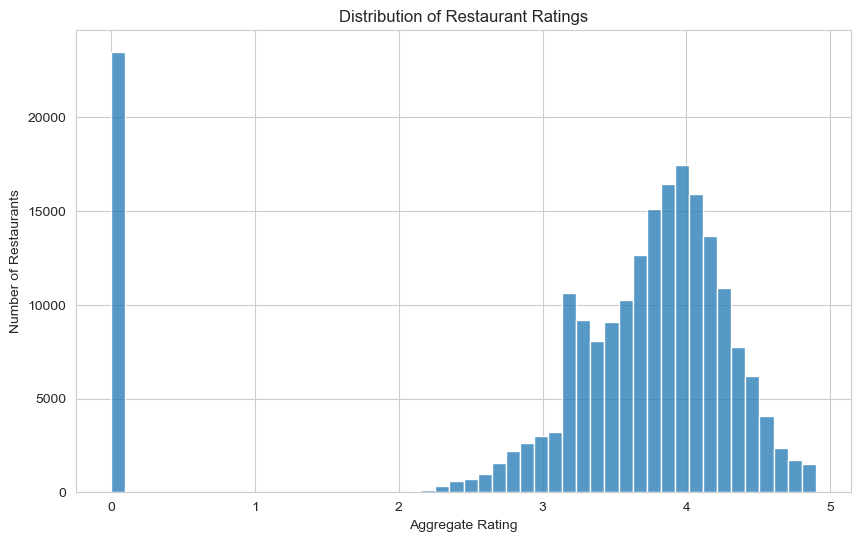

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['aggregate_rating'], bins=50)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.savefig('../dashboards/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\91928\AppData\Local\Temp\ipykernel_21552\1762619641.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_stats['avg_rating'], y = city_stats.index, palette='viridis')


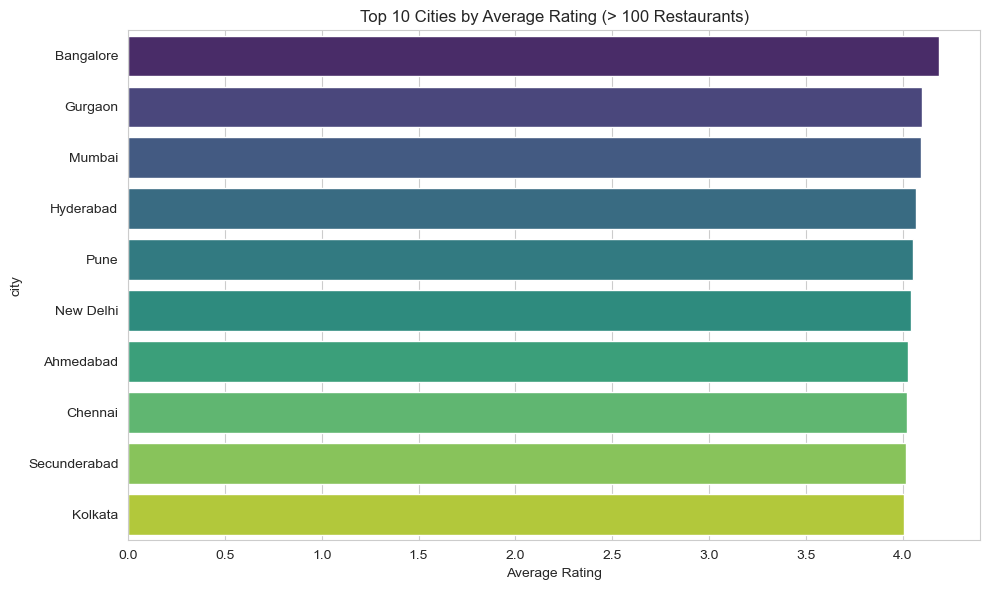

In [6]:
rated = df[df['aggregate_rating']>0]

city_stats = (
    rated.groupby('city')
    .agg(avg_rating=('aggregate_rating', 'mean'),
         n_restaurants=('res_id', 'count'))
    .query('n_restaurants >= 100')  # ignore cities with too few restaurants
    .sort_values('avg_rating', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_stats['avg_rating'], y = city_stats.index, palette='viridis')
plt.title('Top 10 Cities by Average Rating (> 100 Restaurants)')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.savefig('../dashboards/top_cities_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

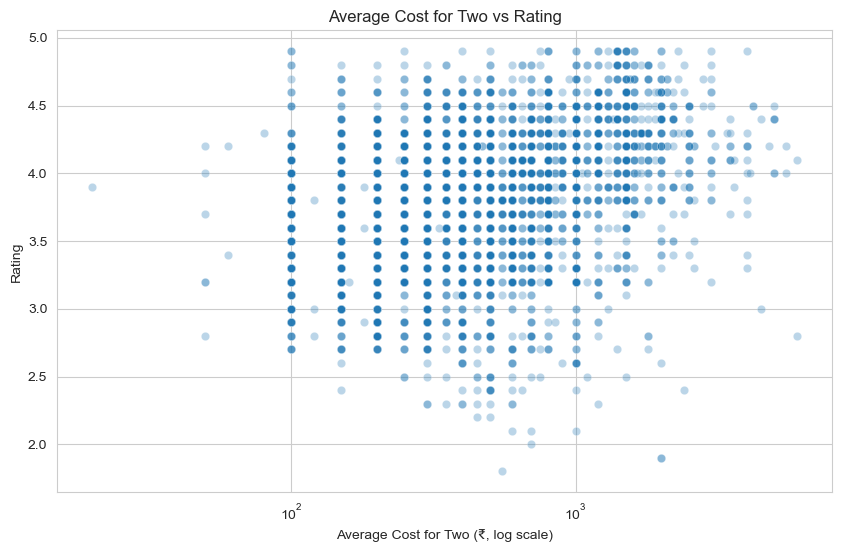

In [8]:
plt.figure(figsize=(10, 6))
sample = rated.sample(5000, random_state=42)  # 5k sample, reproducible
sns.scatterplot(data=sample, x='average_cost_for_two', y='aggregate_rating', alpha=0.3)
plt.xscale('log')
plt.title('Average Cost for Two vs Rating')
plt.xlabel('Average Cost for Two (₹, log scale)')
plt.ylabel('Rating')
plt.savefig('../dashboards/price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()